In [1]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import numpy as np 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
import joblib

In [2]:
df = pd.read_csv('data/california_housing.csv')
df.head(10)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


In [3]:
# Input features
X = df.drop("Price", axis=1)

# Target
y = df["Price"]

print("\nX Shape:", X.shape)
print("y Shape:", y.shape)


X Shape: (20640, 8)
y Shape: (20640,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

print("\nTrain Shape:", X_train.shape)
print("Test Shape :", X_test.shape)


Train Shape: (14448, 8)
Test Shape : (6192, 8)


In [5]:
scaler = StandardScaler()

In [6]:
scaler.fit(X_train)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [7]:
X_train_scaled = scaler.transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [8]:
# Initialize model
linear_model = LinearRegression()

In [9]:
# Train
linear_model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [10]:
predictions = linear_model.predict(X_test_scaled)

print(predictions[:10])

[0.72604907 1.76743383 2.71092161 2.83514727 2.60695807 2.01073856
 2.64067386 2.16706161 2.74012056 3.90361526]


In [11]:
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

In [12]:
print("\n===== Linear Regression Evaluation =====")

print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)


===== Linear Regression Evaluation =====
MSE : 0.5305677824766752
RMSE: 0.7284008391515452
MAE : 0.5272474538305952
R2  : 0.5957702326061665


In [13]:
sns.set_theme(style="darkgrid", palette="pastel")

In [14]:
plt.rcParams.update({
    "grid.color": "0.3",
    "axes.facecolor": "#1c1c1c",
    "figure.facecolor": "#121212",
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white"
})

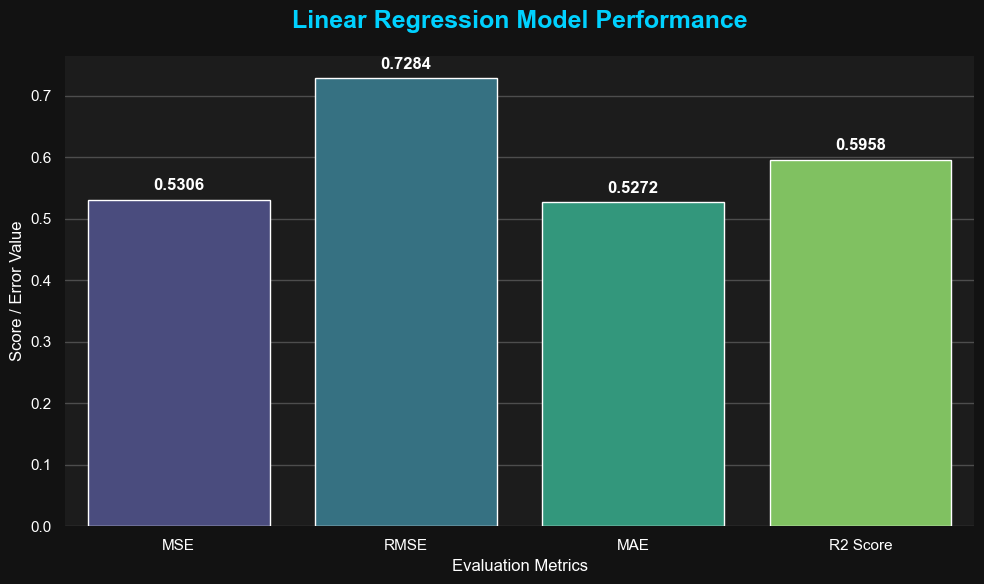

In [18]:
metrics_data = {
    'Metric': ['MSE', 'RMSE', 'MAE', 'R2 Score'],
    'Value': [mse, rmse, mae, r2]
}
df_metrics = pd.DataFrame(metrics_data)

plt.figure(figsize=(10, 6))

# Sử dụng barplot của seaborn với màu sắc hiện đại
ax = sns.barplot(
    x='Metric', 
    y='Value', 
    data=df_metrics, 
    hue='Metric',       # Gán màu theo từng cột
    palette='viridis',    # Palette 'flare' hoặc 'viridis' rất đẹp trên nền tối
    legend=False
)

# 4. Thêm số liệu thực tế trên đầu cột
for p in ax.patches:
    ax.annotate(f'{p.get_height():.4f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 10), 
                textcoords='offset points',
                color='white',
                fontsize=12,
                fontweight='bold')

# Tinh chỉnh tiêu đề
plt.title('Linear Regression Model Performance', fontsize=18, fontweight='bold', color='#00d1ff', pad=20)
plt.ylabel('Score / Error Value')
plt.xlabel('Evaluation Metrics')

# Loại bỏ viền thừa
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.savefig("reports/images/linear_regression_results/performance.png")
plt.show()

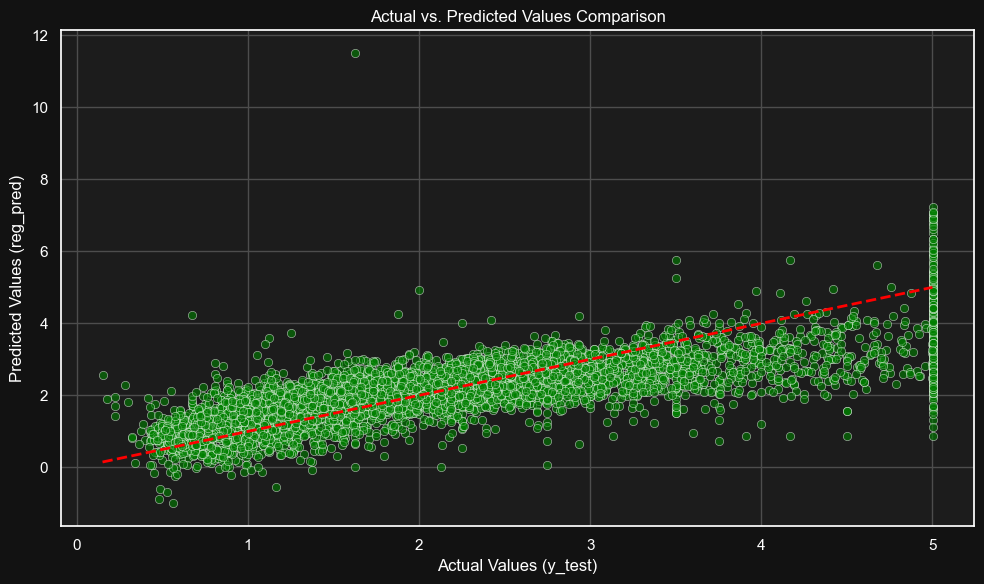

In [21]:
plt.figure(figsize=(10, 6))

# Plot scatter using seaborn
sns.scatterplot(x=y_test, y=predictions, alpha=0.6, color='green', edgecolor='w')

# Plot a reference diagonal line (if predictions are perfect, points will lie on this line)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--')

plt.xlabel('Actual Values (y_test)')
plt.ylabel('Predicted Values (reg_pred)')
plt.title('Actual vs. Predicted Values Comparison')
plt.tight_layout()
plt.savefig("reports/images/linear_regression_results/actual_predicted_scatter.png")
plt.show()

# **Residuals**

In [22]:
residuals = y_test - predictions

In [23]:
residuals

20046   -0.249049
3024    -1.309434
15663    2.289088
20484   -0.649147
9814     0.173042
           ...   
17505    0.155059
13512   -0.237516
10842    0.109345
16559   -0.379714
5786     0.270559
Name: Price, Length: 6192, dtype: float64

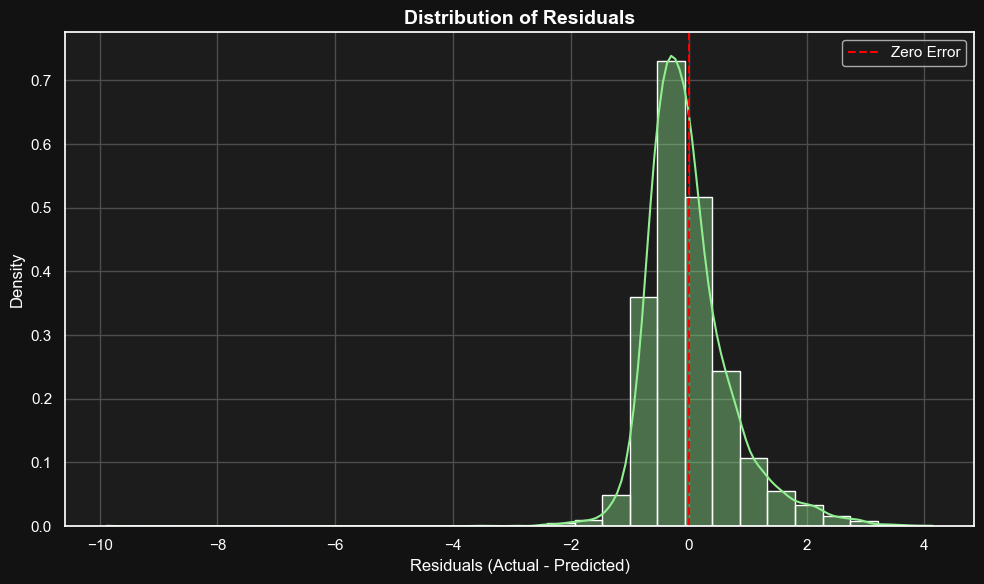

In [37]:
plt.figure(figsize=(10, 6))

# Improve the plot by combining a histogram with a KDE curve
# kde=True: Adds the kernel density estimate line
# stat="density": Normalizes the histogram so the area equals 1
sns.histplot(residuals, kde=True, color='lightgreen', bins=30, stat="density", alpha=0.4)

# Add a vertical dashed line at 0
# Ideally, residuals should be normally distributed around zero
plt.axvline(x=0, color='red', linestyle='--', label='Zero Error')

# Labeling for clarity
plt.xlabel('Residuals (Actual - Predicted)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Distribution of Residuals', fontsize=14, fontweight='bold')
plt.legend()

plt.tight_layout()
plt.savefig("reports/images/linear_regression_results/residuals.png")
plt.show()

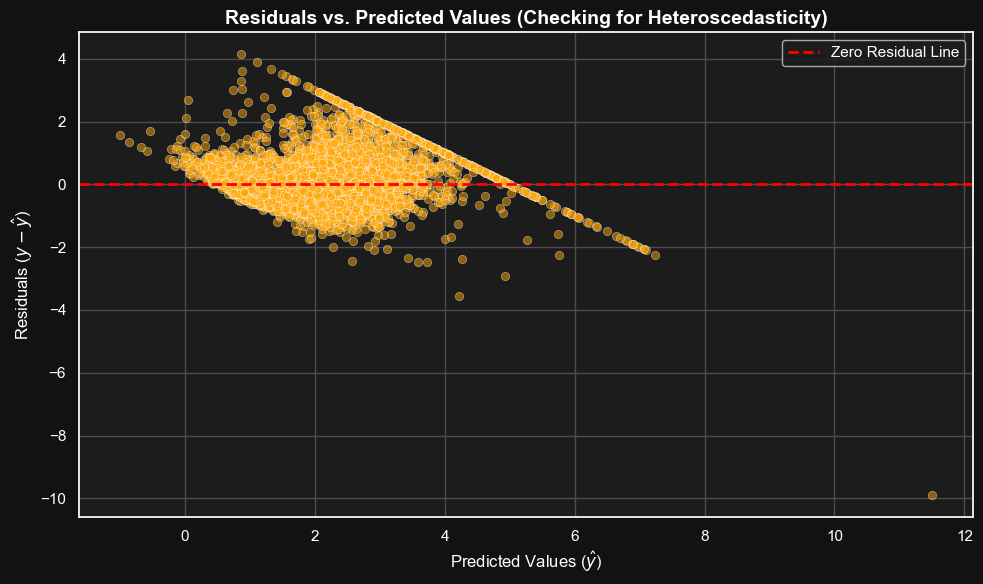

In [30]:
# Scatter plot with respect to prediction and residuals
plt.figure(figsize=(10, 6))

# Use sns.scatterplot for better control over aesthetics
sns.scatterplot(x=predictions, y=residuals, alpha=0.5, color='orange', edgecolor='w')

# Add a horizontal line at y=0
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Residual Line')

# FIX: Use 'r' before the string to avoid SyntaxWarning with LaTeX backslashes
plt.xlabel(r'Predicted Values ($\hat{y}$)', fontsize=12)
plt.ylabel(r'Residuals ($y - \hat{y}$)', fontsize=12)

plt.title('Residuals vs. Predicted Values (Checking for Heteroscedasticity)', fontsize=14, fontweight='bold')
plt.legend()
plt.savefig("reports/images/linear_regression_results/prediction_residuals_scatter.png")
plt.tight_layout()
plt.show()

In [31]:
# Save scaler
joblib.dump(scaler, "models/linear_regression_model/scaler.pkl")

# Save model
joblib.dump(linear_model, "models/linear_regression_model/linear_regression.pkl")

print("\nScaler and model saved!")


Scaler and model saved!


In [33]:
# Load scaler
scaler = joblib.load("models/linear_regression_model/scaler.pkl")

# Load model
model = joblib.load("models/linear_regression_model/linear_regression.pkl")

print("Model loaded successfully!")

Model loaded successfully!


In [34]:
sample = pd.DataFrame({
    "MedInc": [8.3252],
    "HouseAge": [41.0],
    "AveRooms": [6.9841],
    "AveBedrms": [1.0238],
    "Population": [322.0],
    "AveOccup": [2.5556],
    "Latitude": [37.88],
    "Longitude": [-122.23]
})

In [35]:
sample_scaled = scaler.transform(sample)

In [36]:
prediction = model.predict(sample_scaled)

print("\nPredicted Price:", prediction[0])


Predicted Price: 4.143330144542771
